# Complete Model Building Code

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 1. Data Loading and Initial Setup
file_name = "Data/NASA_AirQuality_Excel_Analysis.xlsx"
df_full = pd.read_excel(file_name)
# Stripping all whitespace from column names
df_full.columns = df_full.columns.str.strip()

df_full["Date"] =pd.to_datetime(df_full["Date"])
df_full.set_index("Date", inplace = True)
if "AQI_Category" in df_full.columns:
    df_full.drop("AQI_Category", axis = 1, inplace = True)   

In [3]:
# 2. Feature Engineering 
# 2.1 Temporal Features
df_full["Year"] = df_full.index.year
df_full["Month"] = df_full.index.month
df_full["DayOfWeek"] = df_full.index.dayofweek
# Correct way to handle WeekOfYear extraction
df_full["WeekOfYear"] = df_full.index.isocalendar().week.astype(int)
df_full["IsWeekend"] = (df_full.index.dayofweek >= 5).astype(int)

# 2.2 Lag and Window Features (Grouped by City)
df_full["AQI_lag_1"] = df_full.groupby("City")["AQI"].shift(1)
df_full["PM2.5_MA_7"] = df_full.groupby("City")["PM2.5"].transform(lambda x: x.rolling(window = 7, min_periods = 1).mean())

# 2.3 Interaction Feature
df_full["Temp_Humidity_Interaction"] = df_full["Temperature"] * df_full["Humidity"]


In [4]:
# 3. City Selection and Data Cleaning
city_name = "Delhi"
df = df_full[df_full["City"] == city_name].copy()
df.drop("City", axis = 1, inplace = True)
df.dropna(inplace = True)

In [5]:
# 4. Define Features (X) and Target (y)
features = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", 
            "Temperature", "Humidity", "WindSpeed", "Rainfall", "Pressure", "Visibility", "UVIndex",
            "Year", "Month", "DayOfWeek", "WeekOfYear", "IsWeekend",
            "AQI_lag_1", "PM2.5_MA_7", "Temp_Humidity_Interaction"
]
target = "AQI"

In [6]:
# 5. Time-Series Data Partitioning (Chronological Split)
split_point = int(len(df) * 0.8)
train = df.iloc[:split_point]
test = df.iloc[split_point:]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

In [7]:
# 6. Model Training (Random Forest Regressor)
print(f"Starting Random Forest training for {city_name}...")
rf_model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 10,
    random_state = 42, 
    n_jobs = -1
)
rf_model.fit(X_train, y_train)

Starting Random Forest training for Delhi...


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# 7. Model Prediction and Evaluation
y_pred = rf_model.predict(X_test)
y_baseline = X_test["AQI_lag_1"]

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))

print(f"\n--- Model Evaluation for {city_name} (Random Forest) ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} (Baseline: {baseline_rmse:.2f})")
print(f"R-squared (R2): {r2:.4f}")


--- Model Evaluation for Delhi (Random Forest) ---
Root Mean Squared Error (RMSE): 7.45 (Baseline: 50.17)
R-squared (R2): 0.9590


In [9]:
# 8. Plotting Results and Feature Importance 
test_results = test.copy()
test_results["AQI_Actual"] = y_test
test_results["AQI_Predicted"] = y_pred

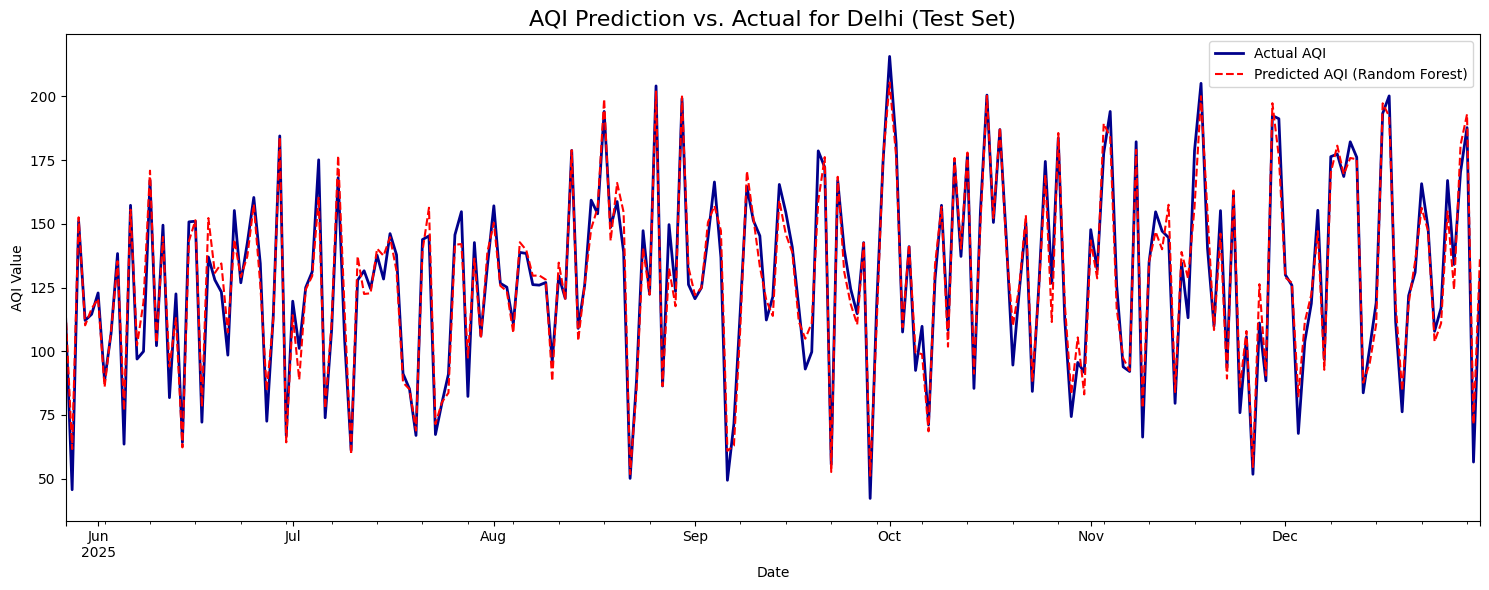

In [10]:
# Plot 1: Actual vs Predicted Time Series
fig, ax = plt.subplots(figsize=(15, 6))
test_results["AQI_Actual"].plot(ax = ax, label = "Actual AQI", linewidth = 2, color = "darkblue")
test_results["AQI_Predicted"].plot(ax = ax, label = "Predicted AQI (Random Forest)", linewidth = 1.5, linestyle = "--", color = "red")
ax.set_title(f"AQI Prediction vs. Actual for {city_name} (Test Set)", fontsize = 16)
ax.set_xlabel("Date")
ax.set_ylabel("AQI Value")
ax.legend()
plt.tight_layout()
plt.savefig("delhi_rf_aqi_prediction.png")


Modeling and Plotting complete.


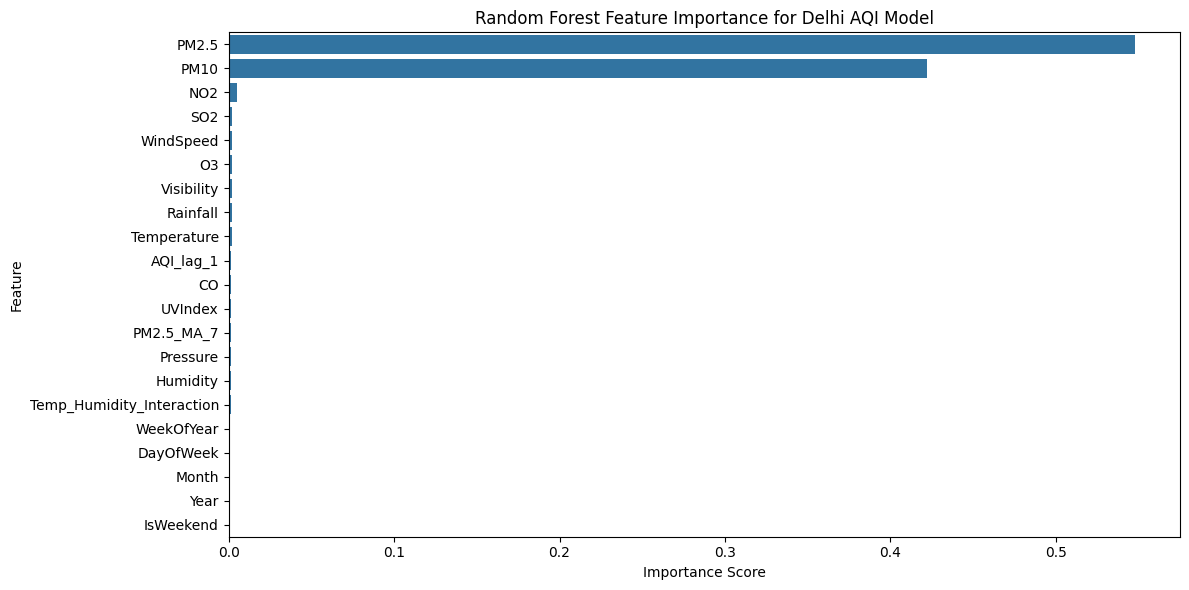

In [11]:
# Plot 2: Feature Importance
feature_importance = pd.Series(rf_model.feature_importances_, index = features).sort_values(ascending = False)
plt.figure(figsize =(12, 6))
sns.barplot(x = feature_importance.values, y = feature_importance.index)
plt.title(f"Random Forest Feature Importance for {city_name} AQI Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("delhi_rf_feature_importance.png")

print("\nModeling and Plotting complete.")